In [1]:
from pathlib import Path
import sys
import numpy as np
from CoolProp.HumidAirProp import HAPropsSI
from CoolProp.CoolProp import PropsSI
sys.path.insert(0, str(Path.cwd().parents[1]))
from Framework.core.config import CaseConfig, GridShape, HeatPump
from Framework.core.geometry import FinnTubedHX
from Framework.models import Frostmodell_V1
from Framework.runtime.simulator_V2 import Simulator
from Framework.visualisation import plot
from Framework.runtime.recorder import ResultRecorder

# Case Definieren

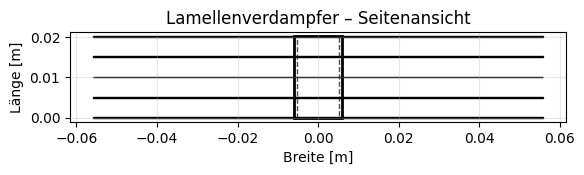

rho_evap = 37.455 kg/m^3, V_evap = 1.125 dm^3, Mass_evap = 0.042 kg
Enthalpie in evaporator at start: 294385 J
Enthalpie in condenser at start: 329768 J
Surface area Evaporator = 39.64 m2
Surface area Condenser = 3.65 m2


In [2]:
sim_run = False
read_data = True

#air
T_a = 5.0
P = 101325
RH = 0.0
v_a = 1.2

#water
T_in_water = 40.0
N_cond = 30

#refrigerant
w_amb_in = HAPropsSI('W','T',T_a+273.15,'P',P,'R', RH)
rho_amb_in = 1.0 / HAPropsSI("Vha","T",T_a+273.15,"P",P,"R",RH)

refrigerant = "R134a"
#at evaportor
x_evap = 0.45
p_ref_evap = PropsSI("P", "T", T_a + 273.15, "Q", 0, refrigerant)
h_ref_evap = PropsSI("H", "T", T_a + 273.15, "Q", x_evap, refrigerant)

#at condenser
x_cond = 0.45
p_ref_cond = PropsSI("P", "T", T_in_water + 273.15, "Q", 0, refrigerant)
h_ref_cond = PropsSI("H", "T", T_in_water + 273.15, "Q", x_cond, refrigerant)

geom = FinnTubedHX(
    n_seg_l = 2,        # -
    n_seg_r = 40,        # -
    stacks = 20,         # -
    n_fin = 5,           # -
    l_fin = 0.05,          # m
    h_fin = 0.05,          # m
    fin_thickness = 0.0002,    # m
    fin_pitch_cc = 0.005,          # m
    d_tube_a = 0.012,          # m
    tube_thickness = 0.0008,       # m
    lambda_fin = 237.0,            # W/mK
    rho_solid = 2700.0,            # kg/m3
    c_solid = 900.0,               # J/kgK
    CP = "serpentine"
)

gs = GridShape(
    t_end = 4*60.0,      # s endtime
    dt = 0.1,           # s time step
    print_output_every_x_it = 20,
    store_grid_every_x_it = 100,

    nx = 100,
    nr = 100,
    ntheta = 90,

    #Model Setup
    cal_air = True,
    cal_frost = True,
    cal_ref = True,

    #dynamic Models
    change_humidity = True,
    change_temperature = False
)

cfg = CaseConfig(
    # air data
    m_dot = v_a*rho_amb_in*(geom.h_fin*geom.fin_gap()*geom.n_seg_r*geom.stacks), # Backup massflow if no fan is used
    T_a = T_a,          # °C temperature air
    v_a = v_a,          # m/s velocity air
    p_a = P,            # Pa pressure air
    RH = RH,            # relative humidity air
    w_amb = w_amb_in,          # kg/kg water vapor moisture content
    rho_amb = rho_amb_in,      # kg/m^3 density air
    v_kin = 1.5e-5,     # m^2/s kinematic viscosity air
    lam = 0.025,        # W/mK heat conduction coefficient air
    c_p_a = 1000,       # J/kgK heat capacity air
    D_std = 2.2e-5,     # m^2/s water vapor diffusion coefficient
    C = 900,            # 1/s empirical water vapor absorbed coefficient
    isv = 2830000,      # J/kg latent heat of desublimation

    # fan model
    use_fan = True,
    fan_dp0 = 150.0,
    fan_V0 = v_a*(geom.h_fin*geom.n_fin*geom.fin_gap()*geom.n_seg_r*geom.stacks),
    dp_clean = 40.0,

    # refrigerant data
    ref_str = refrigerant,
    T_tube = T_a,    # °C tube temperature
    T_ref = T_a,     # °C tube temperature
    p_ref = p_ref_evap,      # Pa Kältemitteldruck
    h_ref = h_ref_evap,          # J/kg spezifische Enthalpie
    m_dot_ref = 0,      # kg/s Massenstrom am Inlet (invalid)
    m_dot_ref_out = 0,      # kg/s Massenstrom am Outlet (invalid)
    x_ref = float("nan"),           # Dampfqualität (0..1), NaN falls einphasig

    # ice data
    rho_i = 920,        # kg/m^3 ice density
    h_sub= 2830000,     # J/kg latent heat of ablimation for water vapor
)

HP = HeatPump(
    N_cond=N_cond,
    p_ref_cond = p_ref_cond,
    h_ref_cond = np.full(N_cond, h_ref_cond, dtype=float),
    T_wall = np.full(N_cond, T_in_water, dtype=float),
    T_water = np.full(N_cond, T_in_water, dtype=float),

    A_flow_cond = 0.01,
    t_plate = 0.001,
    height_cond=1.0,
    length_cond=0.5,
    n_plates=22,
    A_plate = 3.65,
    c_plate = 500,
    rho_plate = 8000.0,
    lamda_plate = 50.0,

    #water
    T_in_water = T_in_water,
    m_water = 0.5,
    c_water = 4200,
    rho_water = 997,

    #vent controller
    use_controller = True
)
plot.plot_finned_tube_side(geom)

V_evap = (geom.n_fin * geom.l_tube() * ((geom.d_rohr_i())**2) / 4) * geom.n_seg_l * geom.n_seg_r * geom.stacks
rho_evap = PropsSI("D", "T", T_a + 273.15, "Q", x_evap, refrigerant)
print(f"rho_evap = {rho_evap:.3f} kg/m^3, V_evap = {V_evap*1000:.3f} dm^3, Mass_evap = {rho_evap * V_evap:.3f} kg")

print(f"Enthalpie in evaporator at start: {h_ref_evap:.0f} J")
print(f"Enthalpie in condenser at start: {h_ref_cond:.0f} J")

print(f"Surface area Evaporator = {geom.A_one_segment()*geom.n_seg_r*geom.n_seg_l*geom.stacks:.2f} m2")
print(f"Surface area Condenser = {HP.A_plate:.2f} m2")

# Simulation laufen lassen

In [3]:
result_file = "results_case_2"

if sim_run:
    sim = Simulator(geom,cfg,HP,result_file)
    results = sim.run(cfg, geom, gs, Frostmodell_V1)

# Resultate speichen/laden

In [4]:
if sim_run:
    data = results.data
    results.to_csv(result_file,data)

if read_data:
    data = ResultRecorder.read_results_csv_json(result_file)
    results = ResultRecorder.from_jsonl(result_file)

# Resultate plotten

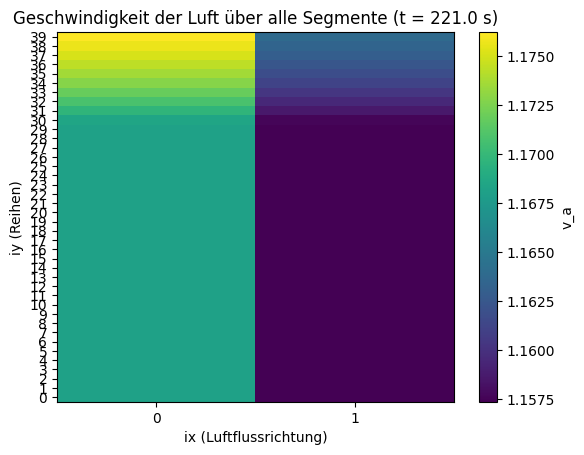

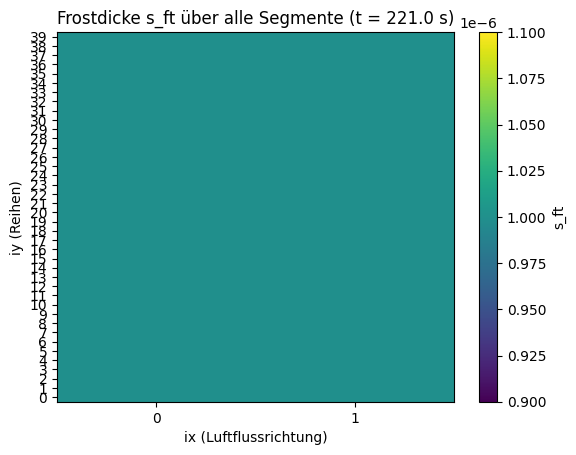

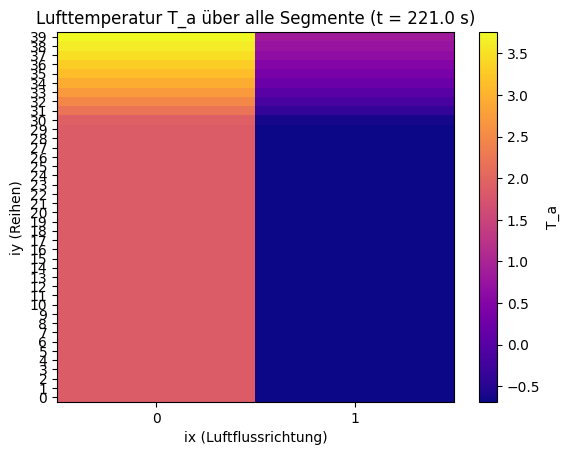

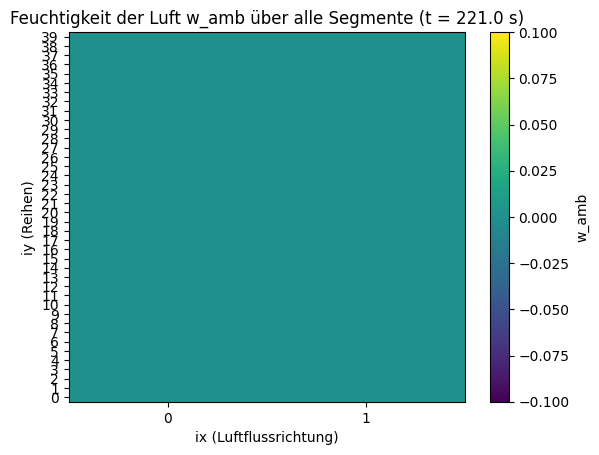

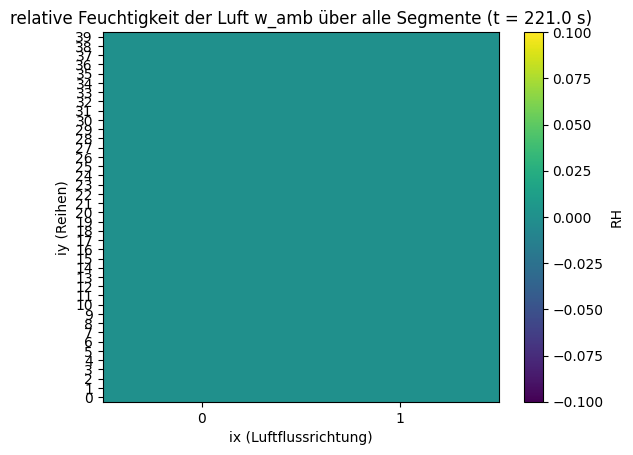

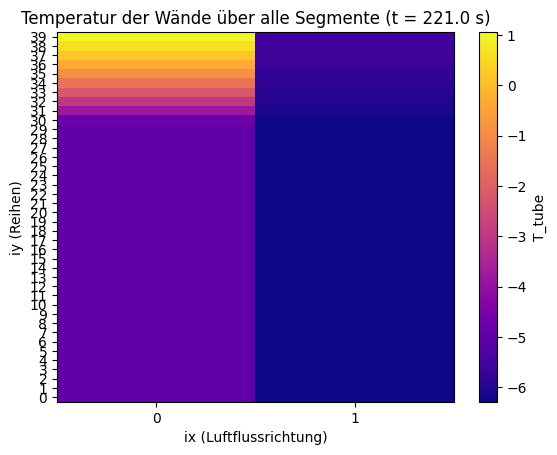

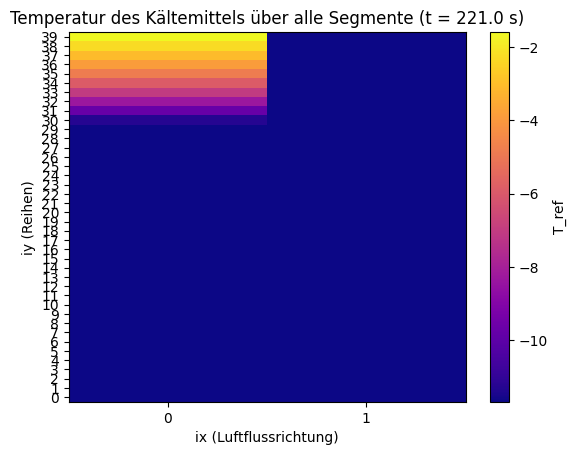

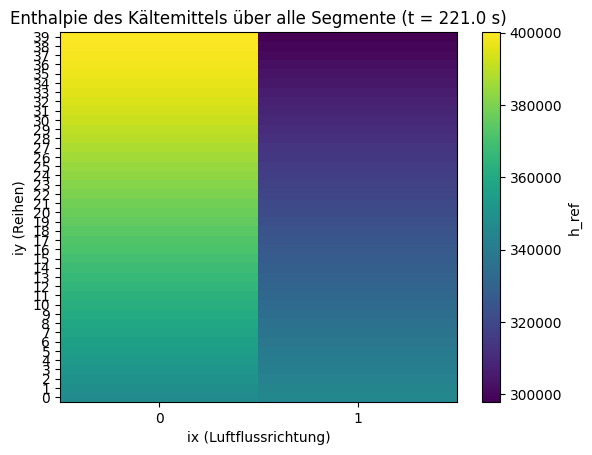

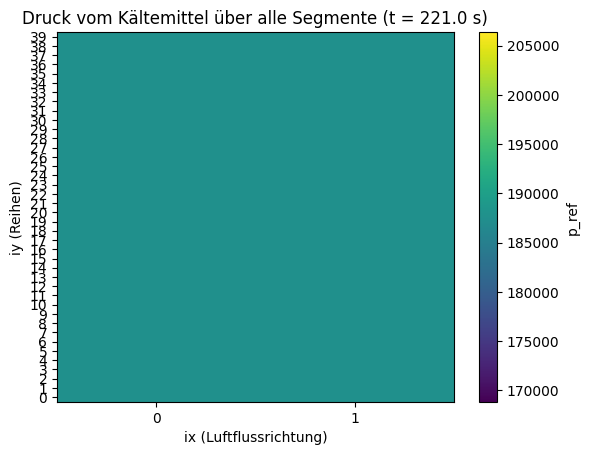

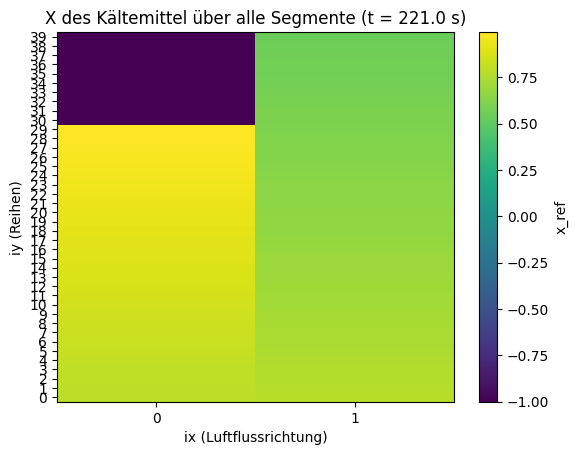

In [5]:
snapshots = results.grid_snapshots

fig, ax, Z_sft = plot.plot_segment_field_grid(
    snapshots,
    field="v_a",
    source="cfg",
    t_idx=-1,          # letzter Zeitschritt
    title="Geschwindigkeit der Luft über alle Segmente",
    cmap="viridis",
)

fig, ax, Z_sft = plot.plot_segment_field_grid(
    snapshots,
    field="s_ft",
    source="st",       # aus SimState
    t_idx=-1,          # letzter Zeitschritt
    title="Frostdicke s_ft über alle Segmente",
    cmap="viridis"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="T_a",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="Lufttemperatur T_a über alle Segmente",
    cmap="plasma"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="w_amb",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="Feuchtigkeit der Luft w_amb über alle Segmente",
    cmap="viridis"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="RH",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="relative Feuchtigkeit der Luft w_amb über alle Segmente",
    cmap="viridis"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="T_tube",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="Temperatur der Wände über alle Segmente",
    cmap="plasma"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="T_ref",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="Temperatur des Kältemittels über alle Segmente",
    cmap="plasma"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="h_ref",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="Enthalpie des Kältemittels über alle Segmente",
    cmap="viridis"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="p_ref",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="Druck vom Kältemittel über alle Segmente",
    cmap="viridis"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="x_ref",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="X des Kältemittel über alle Segmente",
    cmap="viridis"
)

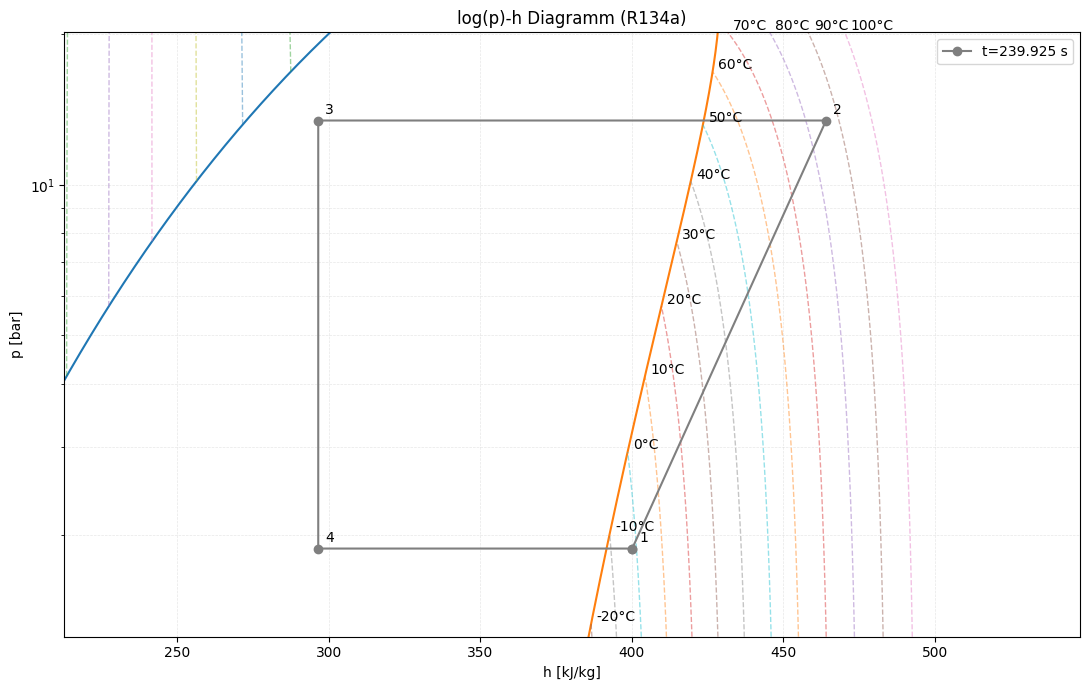

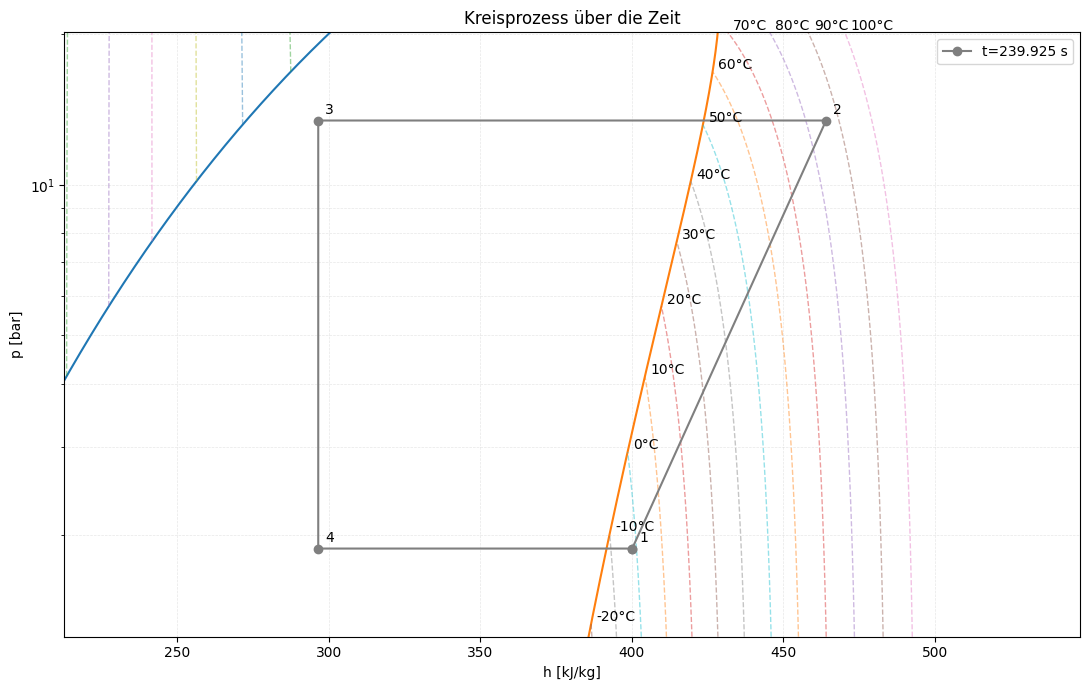

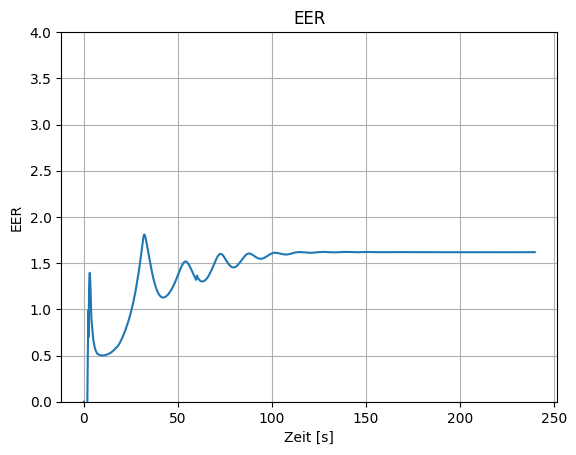

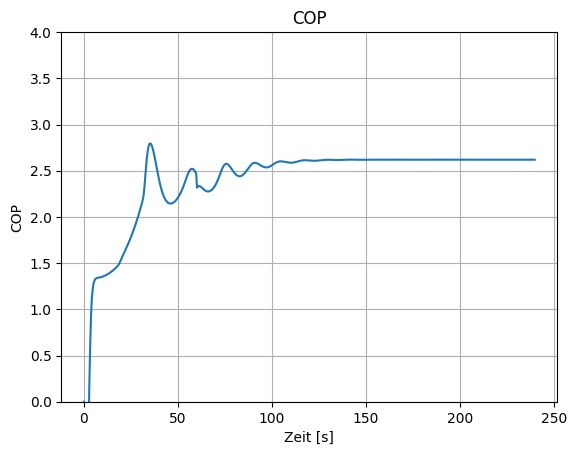

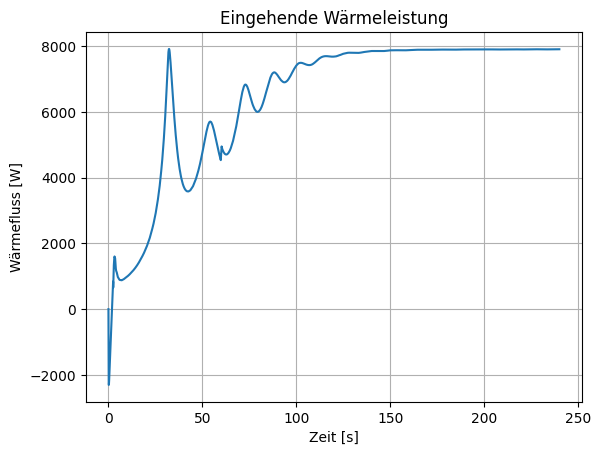

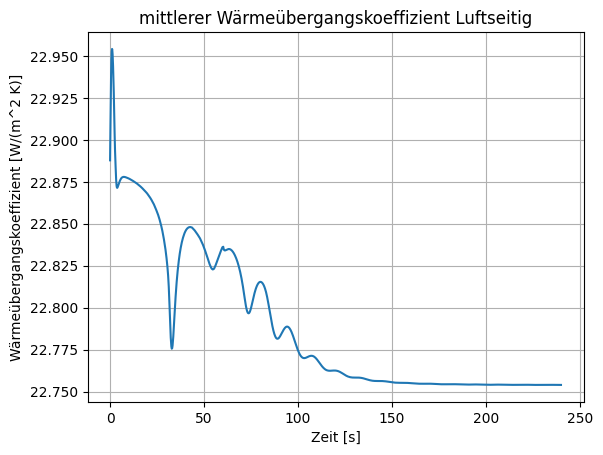

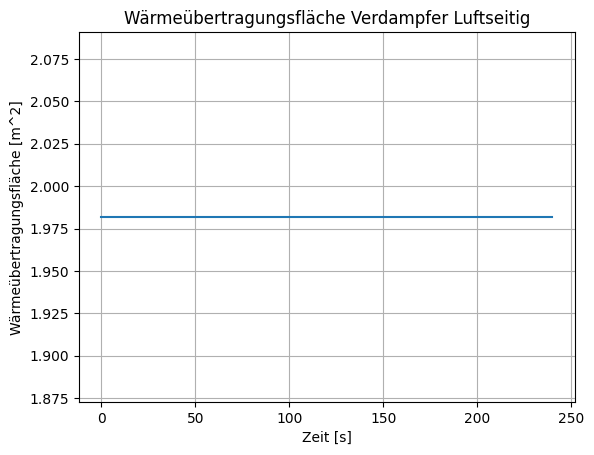

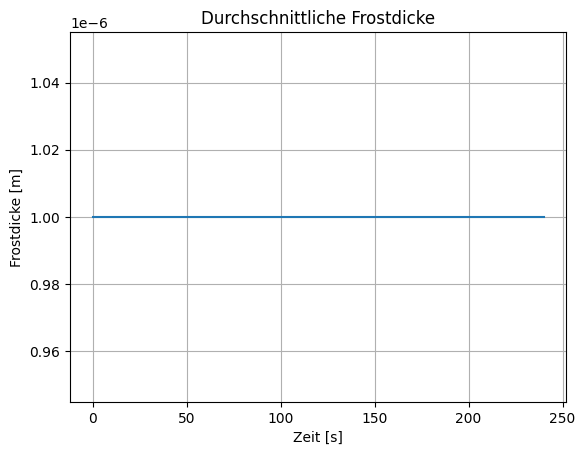

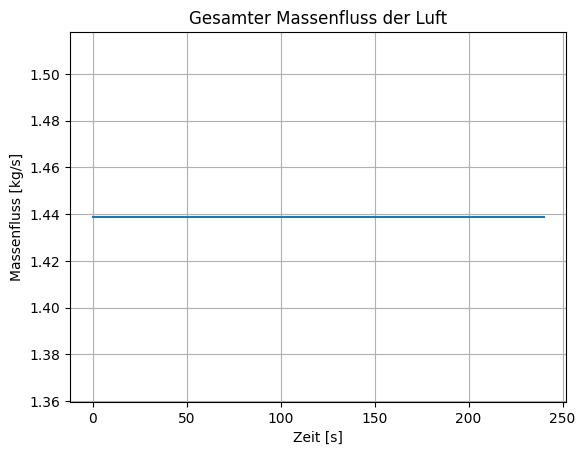

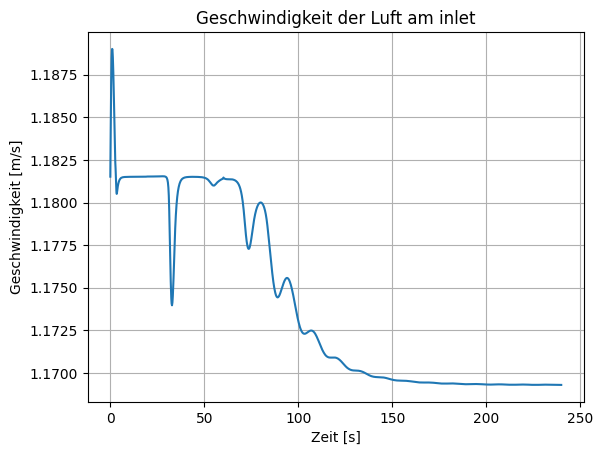

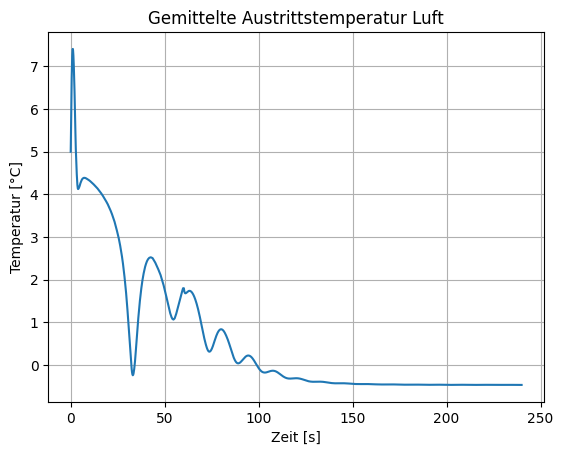

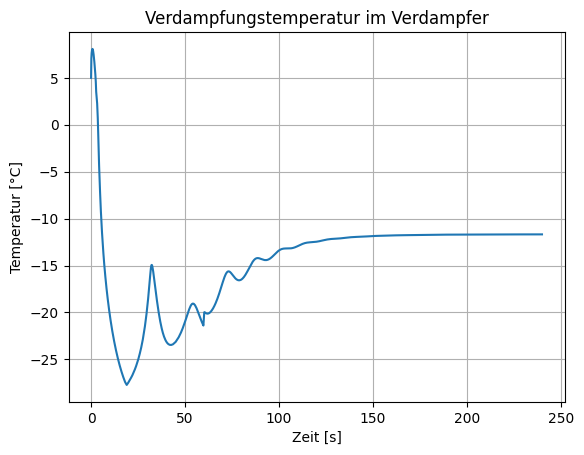

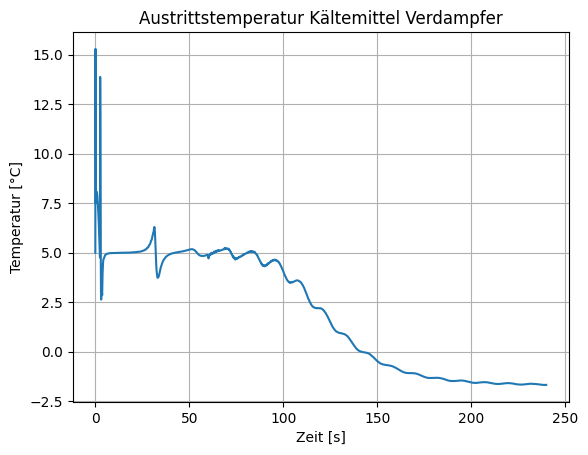

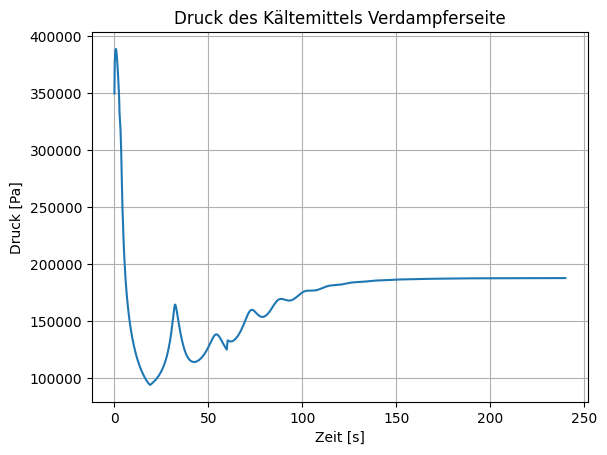

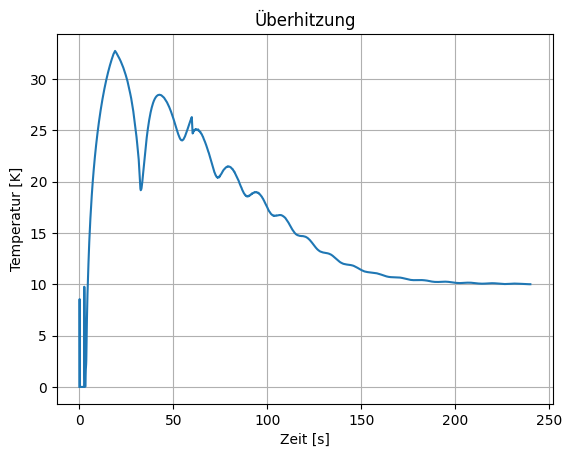

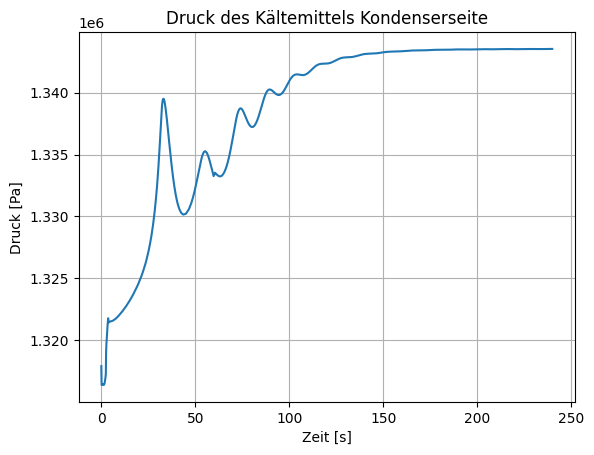

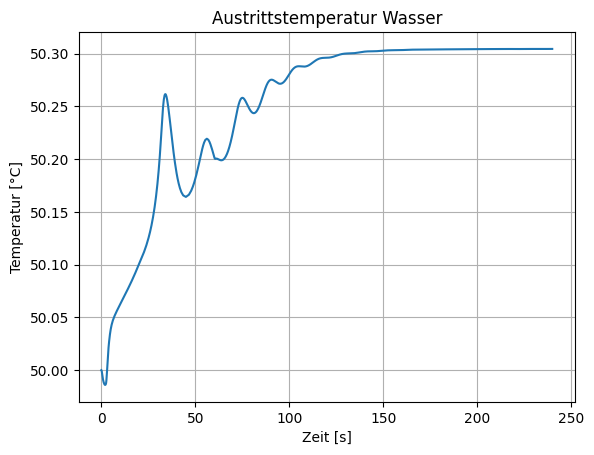

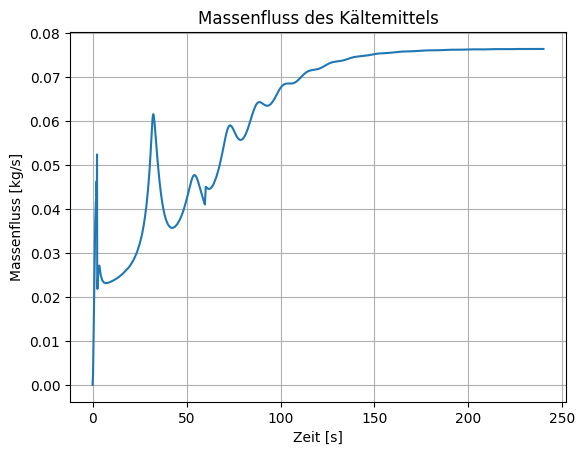

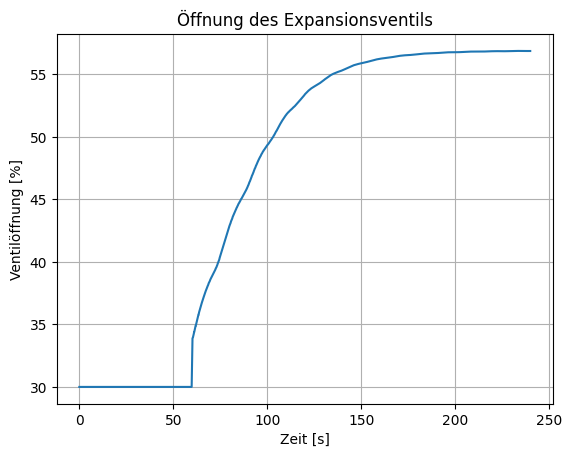

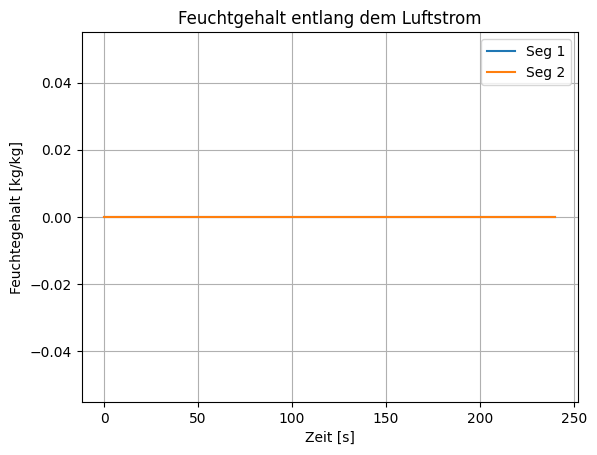

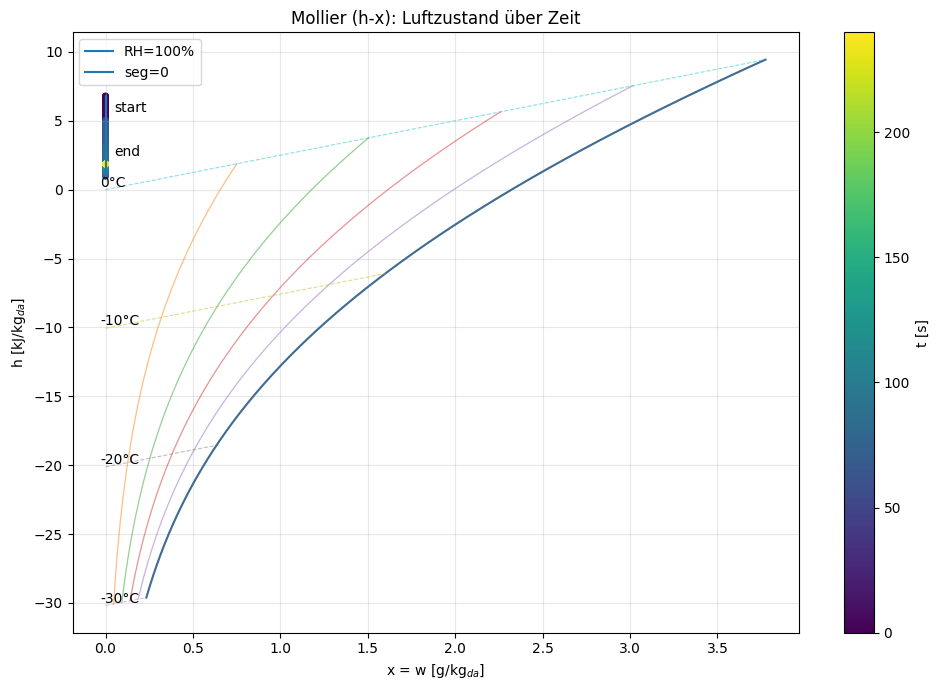

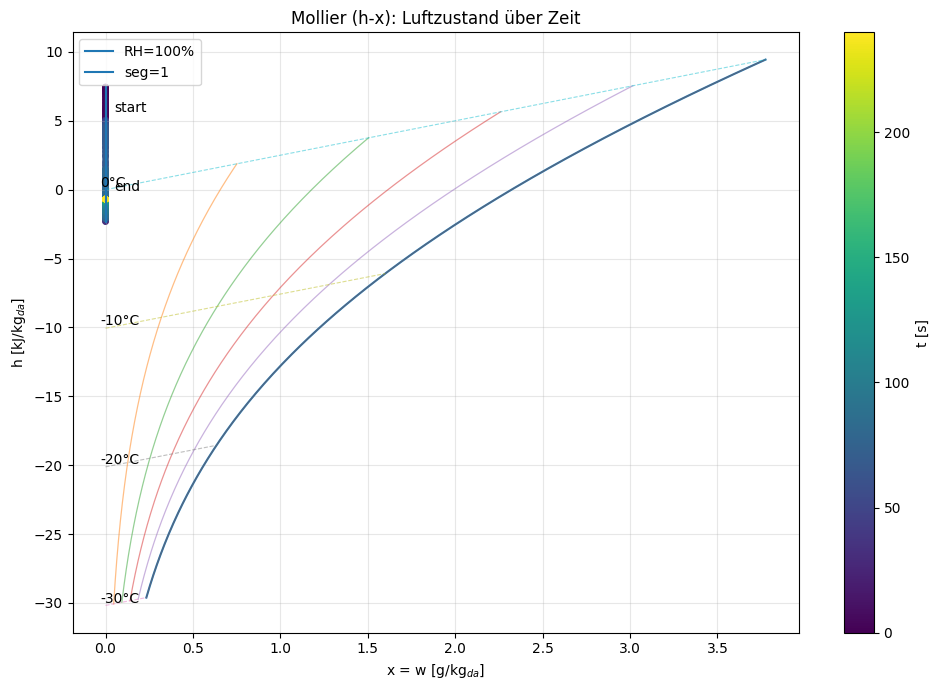

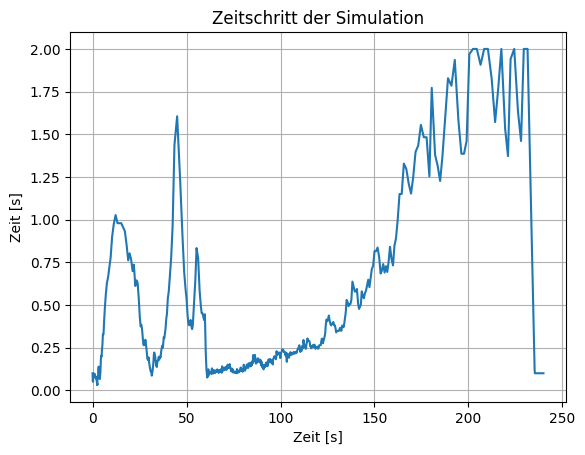

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Zeitschritt der Simulation'}, xlabel='Zeit [s]', ylabel='Zeit [s]'>)

In [6]:
plot.plot_logph_cycles(
    ref=cfg.ref_str,
    t=data["t"],
    cycle_ph=data["cycle_ph"],
    at_time=gs.t_end,
    isotherms=True,
    iso_Ts_C=[-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80,90,100],
    save_path="Plots/logph_at_t.png"
)

plot.plot_logph_cycles(
    ref=cfg.ref_str,
    t=data["t"],
    cycle_ph=data["cycle_ph"],
    t_start=4*60.0,
    t_end=gs.t_end,
    every_s=10*60.0,   # alle x s ein Kreisprozess
    isotherms=True,
    iso_Ts_C=[-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80,90,100],
    title="Kreisprozess über die Zeit",
    save_path="Plots/logph_t_vec.png"
)

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['EER'],
              xlabel="Zeit [s]", ylabel="EER",
              title=f"EER", marker=None, ylimitter=[0, 4],
              save_path="Plots/EER.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['COP'],
              xlabel="Zeit [s]", ylabel="COP",
              title=f"COP", marker=None, ylimitter=[0, 4],
              save_path="Plots/COP.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['Q_evap'],
              xlabel="Zeit [s]", ylabel="Wärmefluss [W]",
              title=f"Eingehende Wärmeleistung", marker=None,
              save_path="Plots/Q_evap.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['h_eff_mean'],
              xlabel="Zeit [s]", ylabel="Wärmeübergangskoeffizient [W/(m^2 K)]",
              title=f"mittlerer Wärmeübergangskoeffizient Luftseitig", marker=None,
              save_path="Plots/h_eff_mean.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['A_evap'],
              xlabel="Zeit [s]", ylabel="Wärmeübertragungsfläche [m^2]",
              title=f"Wärmeübertragungsfläche Verdampfer Luftseitig", marker=None,
              save_path="Plots/A_evap.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['mean_s_ft'],
              xlabel="Zeit [s]", ylabel="Frostdicke [m]",
              title=f"Durchschnittliche Frostdicke", marker=None,
              save_path="Plots/mean_frost.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['m_dot_air'],
              xlabel="Zeit [s]", ylabel="Massenfluss [kg/s]",
              title=f"Gesamter Massenfluss der Luft", marker=None,
              save_path="Plots/m_dot_air.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['v_in_air'],
              xlabel="Zeit [s]", ylabel="Geschwindigkeit [m/s]",
              title=f"Geschwindigkeit der Luft am inlet", marker=None,
              save_path="Plots/v_in_air.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['T_out_air_mean'],
              xlabel="Zeit [s]", ylabel="Temperatur [°C]",
              title=f"Gemittelte Austrittstemperatur Luft", marker=None,
              save_path="Plots/T_out_air.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['T_sat'],
              xlabel="Zeit [s]", ylabel="Temperatur [°C]",
              title=f"Verdampfungstemperatur im Verdampfer", marker=None,
              save_path="Plots/T_evaporation.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['T_out_ref'],
              xlabel="Zeit [s]", ylabel="Temperatur [°C]",
              title=f"Austrittstemperatur Kältemittel Verdampfer", marker=None,
              save_path="Plots/T_out_ref_evap.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['p_ref_evap'],
              xlabel="Zeit [s]", ylabel="Druck [Pa]",
              title=f"Druck des Kältemittels Verdampferseite", marker=None,
              save_path="Plots/P_ref_evap.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['superheating'],
              xlabel="Zeit [s]", ylabel="Temperatur [K]",
              title=f"Überhitzung", marker=None,
              save_path="Plots/superheating.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['p_ref_cond'],
              xlabel="Zeit [s]", ylabel="Druck [Pa]",
              title=f"Druck des Kältemittels Kondenserseite", marker=None,
              save_path="Plots/P_ref_cond.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['T_out_water'],
              xlabel="Zeit [s]", ylabel="Temperatur [°C]",
              title=f"Austrittstemperatur Wasser", marker=None,
              save_path="Plots/T_out_water.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['m_dot_ref'],
              xlabel="Zeit [s]", ylabel="Massenfluss [kg/s]",
              title=f"Massenfluss des Kältemittels", marker=None,
              save_path="Plots/m_dot_ref.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['valve_pos'],
              xlabel="Zeit [s]", ylabel="Ventilöffnung [%]",
              title=f"Öffnung des Expansionsventils", marker=None,
              save_path="Plots/valve_pos.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['humidity'],
              xlabel="Zeit [s]", ylabel="Feuchtegehalt [kg/kg]",
              title=f"Feuchtgehalt entlang dem Luftstrom", marker=None,
              labels=["Seg 1","Seg 2","Seg 3","Seg 4","Seg 5"],
              save_path="Plots/humidity.png")

plot.plot_mollier_hx_time(data["t"], data["humidity"], data["air_temp_l"],P=P, seg_idx=0,iso_Ts_C=[-30,-20,-10,0],T_bg_min=-30,T_bg_max=0,save_path="Plots/mollier_seg_0.png")
plot.plot_mollier_hx_time(data["t"], data["humidity"], data["air_temp_l"],P=P, seg_idx=1,iso_Ts_C=[-30,-20,-10,0],T_bg_min=-30,T_bg_max=0,save_path="Plots/mollier_seg_1.png")

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['dt'],
              xlabel="Zeit [s]", ylabel="Zeit [s]",
              title=f"Zeitschritt der Simulation", marker=None,
              save_path="Plots/time_step.png")

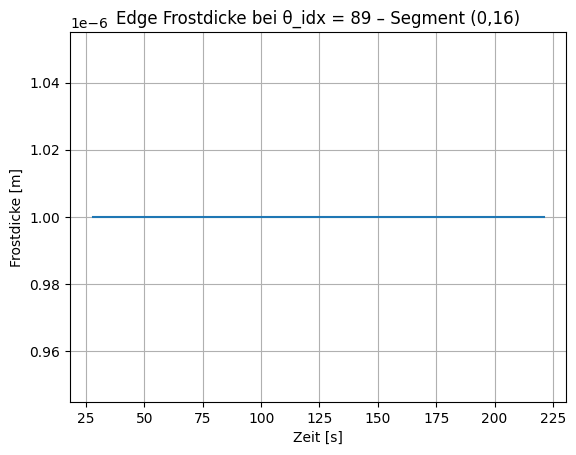

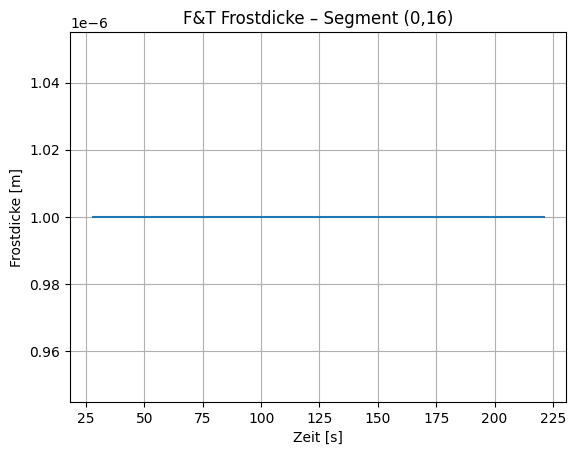

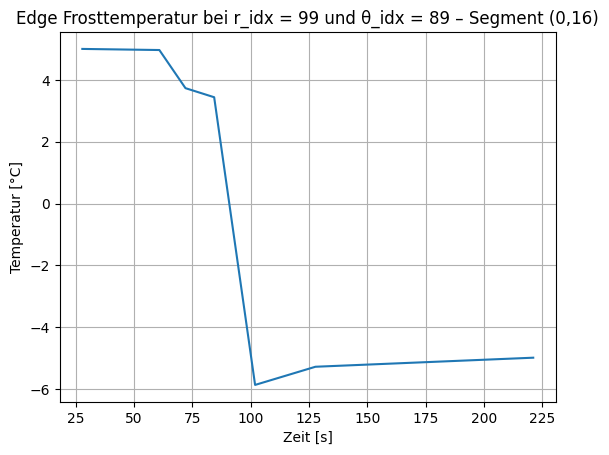

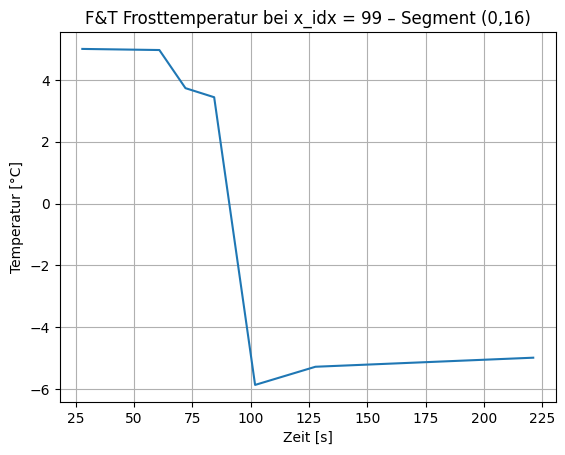

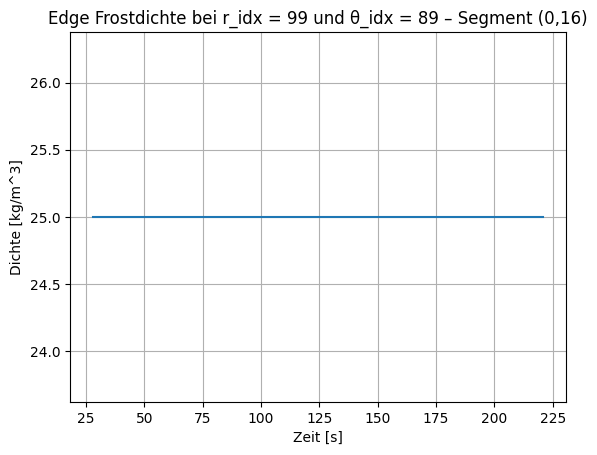

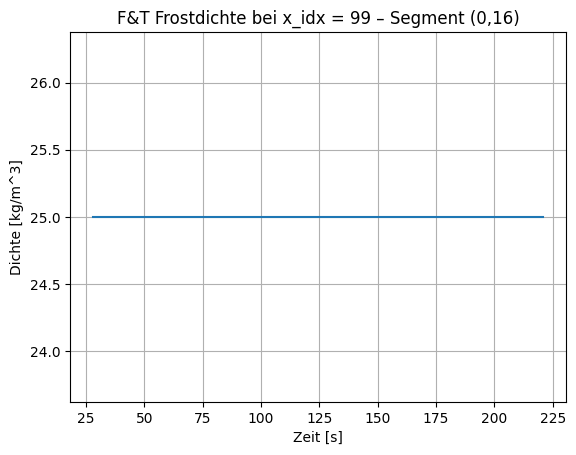

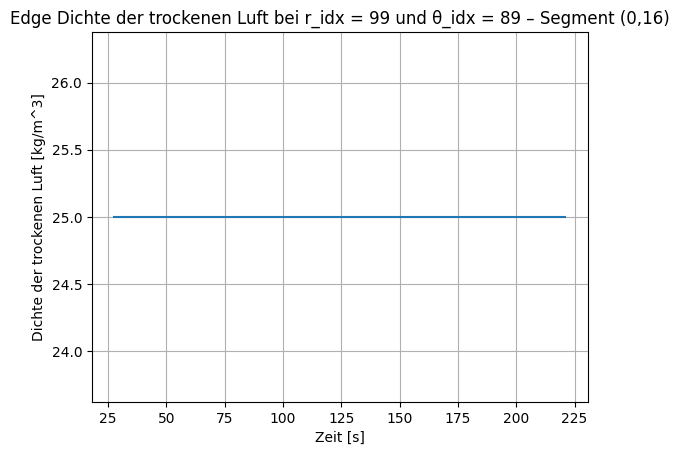

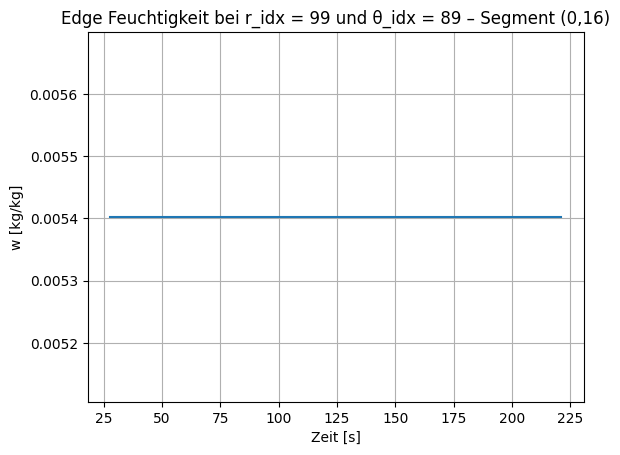

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Edge Feuchtigkeit bei r_idx = 99 und θ_idx = 89 – Segment (0,16)'}, xlabel='Zeit [s]', ylabel='w [kg/kg]'>)

In [7]:
# Segment auswählen
ix, iy = 0, 16

plot_r = int(gs.nr-1)
plot_x = int(gs.nx-1)
plot_theta = int(gs.ntheta-1)
plot_time = int(max(data['t'])/gs.dt)

t, s_e = plot.extract_segment_timeseries_from_snapshots(snapshots, "s_e", ix, iy)
plot.plot_any(kind="time vs 1D(theta)",
              x=t, y=s_e,
              xlabel="Zeit [s]", ylabel="Frostdicke [m]",
              title=f"Edge Frostdicke bei θ_idx = {plot_theta} – Segment ({ix},{iy})",
              theta_idx=plot_theta, marker=None)
t, s_ft = plot.extract_segment_timeseries_from_snapshots(snapshots, "s_ft", ix, iy)
plot.plot_any(kind="time vs any",
              x=t, y=s_ft,
              xlabel="Zeit [s]", ylabel="Frostdicke [m]",
              title=f"F&T Frostdicke – Segment ({ix},{iy})", marker=None)
t, T_e = plot.extract_segment_timeseries_from_snapshots(snapshots, "T_e", ix, iy)
plot.plot_any(kind="time vs 2D(r,theta)",
              x=t, y=T_e,
              xlabel="Zeit [s]", ylabel="Temperatur [°C]",
              title=f"Edge Frosttemperatur bei r_idx = {plot_r} und θ_idx = {plot_theta} – Segment ({ix},{iy})",
              r_idx=plot_r, theta_idx=plot_theta, marker=None)
t, T_ft = plot.extract_segment_timeseries_from_snapshots(snapshots, "T_ft", ix, iy)
plot.plot_any(kind="time vs 1D(r)",
              x=t, y=T_ft,
              xlabel="Zeit [s]", ylabel="Temperatur [°C]",
              title=f"F&T Frosttemperatur bei x_idx = {plot_x} – Segment ({ix},{iy})",
              r_idx=plot_x, marker=None)
t, rho_e = plot.extract_segment_timeseries_from_snapshots(snapshots, "rho_e", ix, iy)
plot.plot_any(kind="time vs 2D(r,theta)",
              x=t, y=rho_e,
              xlabel="Zeit [s]", ylabel="Dichte [kg/m^3]",
              title=f"Edge Frostdichte bei r_idx = {plot_r} und θ_idx = {plot_theta} – Segment ({ix},{iy})",
              r_idx=plot_r, theta_idx=plot_theta, marker=None)
t, rho_ft = plot.extract_segment_timeseries_from_snapshots(snapshots, "rho_ft", ix, iy)
plot.plot_any(kind="time vs 1D(r)",
              x=t, y=rho_ft,
              xlabel="Zeit [s]", ylabel="Dichte [kg/m^3]",
              title=f"F&T Frostdichte bei x_idx = {plot_x} – Segment ({ix},{iy})",
              r_idx=plot_x, marker=None)
t, rho_a_e = plot.extract_segment_timeseries_from_snapshots(snapshots, "rho_e", ix, iy)
plot.plot_any(kind="time vs 2D(r,theta)",
              x=t, y=rho_a_e,
              xlabel="Zeit [s]", ylabel="Dichte der trockenen Luft [kg/m^3]",
              title=f"Edge Dichte der trockenen Luft bei r_idx = {plot_r} und θ_idx = {plot_theta} – Segment ({ix},{iy})",
              r_idx=plot_r, theta_idx=plot_theta, marker=None)
t, w_e = plot.extract_segment_timeseries_from_snapshots(snapshots, "w_e", ix, iy)
plot.plot_any(kind="time vs 2D(r,theta)",
              x=t, y=w_e,
              xlabel="Zeit [s]", ylabel="w [kg/kg]",
              title=f"Edge Feuchtigkeit bei r_idx = {plot_r} und θ_idx = {plot_theta} – Segment ({ix},{iy})",
              r_idx=plot_r, theta_idx=plot_theta, marker=None)

In [8]:

_, T_e      = plot.extract_segment_timeseries_from_snapshots(snapshots, "T_e",      ix, iy)
plot.plot_spatial_slice(
    T_e, vary="r", t_idx=plot_time, theta_idx=plot_theta,
    title=f"T_e(r) bei t={data['t'][plot_time]} s, θ_idx = {plot_theta} – Segment ({ix},{iy})", xlabel="r_idx", ylabel="T_e [°C]", marker=None
)
_, T_ft      = plot.extract_segment_timeseries_from_snapshots(snapshots, "T_ft",      ix, iy)
plot.plot_spatial_slice(
    T_ft, vary="r", t_idx=plot_time, theta_idx=plot_theta,
    title=f"T_ft(r) bei t={data['t'][plot_time]} s, θ_idx = {plot_theta} – Segment ({ix},{iy})", xlabel="r_idx", ylabel="T_e [°C]", marker=None
)
_, rho_e      = plot.extract_segment_timeseries_from_snapshots(snapshots, "rho_e",      ix, iy)
plot.plot_spatial_slice(
    rho_e, vary="r", t_idx=plot_time, theta_idx=plot_theta,
    title=f"rho_e(r) bei t={data['t'][plot_time]} s, θ_idx = {plot_theta} – Segment ({ix},{iy})", xlabel="r_idx", ylabel="rho_e [kg/m^3]", marker=None
)
_, w_e      = plot.extract_segment_timeseries_from_snapshots(snapshots, "w_e",      ix, iy)
plot.plot_spatial_slice(
    w_e, vary="r", t_idx=plot_time, theta_idx=plot_theta,
    title=f"w_e(r) bei t={data['t'][plot_time]} s, θ_idx = {plot_theta} – Segment ({ix},{iy})", xlabel="r_idx", ylabel="w_e [kg/kg]", marker=None
)
_, rho_a_e      = plot.extract_segment_timeseries_from_snapshots(snapshots, "rho_a_e",      ix, iy)
plot.plot_spatial_slice(
    rho_a_e, vary="r", t_idx=plot_time, theta_idx=plot_theta,
    title=f"rho_a(r) bei t={data['t'][plot_time]} s, θ_idx = {plot_theta} – Segment ({ix},{iy})", xlabel="r_idx", ylabel="rho_a [kg/m^3]", marker=None
)

IndexError: index 2399 is out of bounds for axis 0 with size 757